In [66]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from fredapi import Fred
import matplotlib.pyplot as plt

MEGACAPS = [
    "AAPL","MSFT","AMZN","GOOGL", "NVDA","JNJ","JPM","V",
    "MA","PG","HD","DIS","BAC","WMT","TSLA","ADBE","NFLX","INTC"
]

BENCHMARK = "SPY" 

START = "2024-01-01"
END = "2025-01-01"

In [78]:
load_dotenv()
fred_key = os.environ["FRED_API_KEY"]

fred = Fred(api_key=fred_key)   
rf_annual = fred.get_series(
    "DTB3",
    observation_start=START,
    observation_end=END
)

rf_annual.to_csv("../data/DTB3.csv")
rf_daily = (np.log(1 + rf_annual/100) / 252).fillna(0)
rf_daily = rf_daily.iloc[1:-1].to_frame().reset_index(names="Date").rename(columns={0:"rf_daily"})
rf_daily["Date"] = pd.to_datetime(rf_daily["Date"])

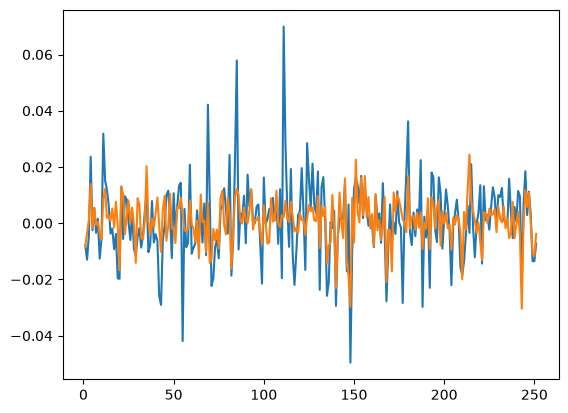

In [81]:
df = pd.read_csv("../data/AAPL.csv")
benchmark_df = pd.read_csv("../data/SPY.csv")

df["Date"] = pd.to_datetime(df["Date"])
benchmark_df["Date"] = pd.to_datetime(benchmark_df["Date"])

merge_df = pd.merge(benchmark_df, rf_daily, on="Date", how="inner")

benchmark_df["log_return"] = np.log(benchmark_df["Close"]).diff()
benchmark_df["excess_return"] = benchmark_df["log_return"] - merge_df["rf_daily"]

df["log_return"] = np.log(df["Close"]).diff()
df["excess_return"] = df["log_return"] - merge_df["rf_daily"]

plt.plot(df["excess_return"])
plt.plot(benchmark_df["excess_return"])